<a href="https://colab.research.google.com/github/kuruvajayanth12/Neural-Networks-and-Deep-Learning/blob/main/NNDL_EXP10_MAE_RMSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/20


/tmp/ipykernel_1367/260596286.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0113 - val_loss: 0.0014
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 9.6583e-04 - val_loss: 0.0011
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 8.8292e-04 - val_loss: 0.0012
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 8.1648e-04 - val_loss: 8.5618e-04
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 7.3446e-04 - val_loss: 7.7518e-04
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 6.5642e-04 - val_loss: 0.0011
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 5.5651e-04 - val_loss: 7.5803e-04
Epoch 9/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 4.9805e-04 - val_loss: 4.1959e-04
Epoch 10/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 4.2643e-04 - val_loss: 2.9955e-04
Epoch 11/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 3.0598e-04 - val_loss: 2.3897e-04
Epoch 12/20
57

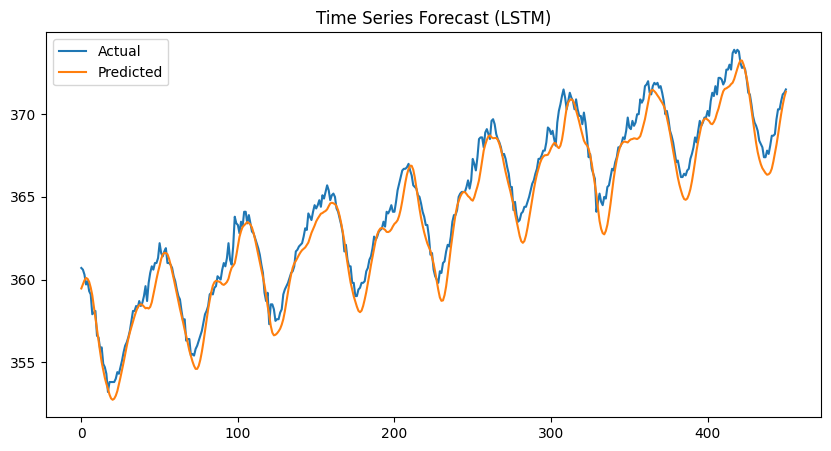

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import statsmodels.api as sm

# -----------------------------
# 1. Load Dataset (built-in)
# -----------------------------
data = sm.datasets.co2.load_pandas().data

# Fill missing values
data = data.fillna(method='ffill')

# Use CO2 as "temperature-like" time series
series = data['co2'].values.reshape(-1, 1)

# -----------------------------
# 2. Normalize
# -----------------------------
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series)

# -----------------------------
# 3. Create Sequences
# -----------------------------
def create_dataset(dataset, time_steps=30):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:i + time_steps])
        y.append(dataset[i + time_steps])
    return np.array(X), np.array(y)

time_steps = 30
X, y = create_dataset(series_scaled, time_steps)

# -----------------------------
# 4. Train-Test Split
# -----------------------------
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# -----------------------------
# 5. LSTM Model
# -----------------------------
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(time_steps, 1)),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# -----------------------------
# 6. Train
# -----------------------------
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# -----------------------------
# 7. Predict
# -----------------------------
y_pred = model.predict(X_test)

# Inverse scaling
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# -----------------------------
# 8. Evaluation
# -----------------------------
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

print("MAE:", mae)
print("RMSE:", rmse)

# -----------------------------
# 9. Plot
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.legend()
plt.title("Time Series Forecast (LSTM)")
plt.show()